In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msn

In [2]:
df  = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/swiggy-delivery-time-prediction/refs/heads/main/swiggy%20dataset/swiggy.csv')
df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [4]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [5]:
df.shape

(45593, 20)

In [6]:
df.dtypes

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object

In [7]:
df.sample(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
28220,0x64e5,VADRES17DEL02,36,4.5,0.000000,0.000000,0.020000,0.020000,03-04-2022,10:35:00,10:45:00,conditions Fog,Low,1,Meal,motorcycle,0,No,Urban,(min) 15
21199,0xc946,AGRRES08DEL01,37,4.6,27.160934,78.044095,27.230934,78.114095,14-02-2022,22:55:00,23:10:00,conditions Stormy,Low,1,Snack,motorcycle,0,No,Metropolitian,(min) 22
12329,0x7063,VADRES010DEL02,35,3.7,22.310329,73.169083,22.390329,73.249083,29-03-2022,19:35:00,19:40:00,conditions Stormy,Jam,2,Buffet,motorcycle,0,No,Metropolitian,(min) 35
17405,0x2266,RANCHIRES20DEL01,21,4.7,23.399250,85.390464,23.469250,85.460464,23-03-2022,23:10:00,23:15:00,conditions Cloudy,Low,1,Drinks,scooter,1,No,Metropolitian,(min) 25
9479,0x541d,CHENRES03DEL03,24,4.4,13.091809,80.219104,13.181809,80.309104,04-04-2022,19:00:00,19:15:00,conditions Fog,Medium,1,Drinks,scooter,1,No,Metropolitian,(min) 39
40360,0x44a2,MYSRES07DEL03,29,4.6,12.325461,76.632278,12.415461,76.722278,06-03-2022,18:55:00,19:10:00,conditions Cloudy,Medium,2,Buffet,motorcycle,1,No,Metropolitian,(min) 34
398,0x4b8a,MUMRES08DEL01,26,4.7,19.065838,72.832658,19.175838,72.942658,06-03-2022,21:55:00,22:10:00,conditions Sunny,Jam,2,Drinks,scooter,0,No,Urban,(min) 16
3103,0x7a0c,JAPRES09DEL01,39,4.7,26.911378,75.789034,27.021378,75.899034,23-03-2022,21:45:00,21:55:00,conditions Fog,Jam,0,Buffet,motorcycle,3,Yes,Semi-Urban,(min) 54
8188,0xbbe,PUNERES14DEL03,NaN,NaN,18.516216,73.842527,18.606216,73.932527,02-04-2022,NaN,20:25:00,conditions Windy,Jam,1,Buffet,motorcycle,1,No,Metropolitian,(min) 26
43644,0x4709,JAPRES13DEL02,26,4.9,26.846156,75.802300,26.866156,75.822300,05-04-2022,10:00:00,10:15:00,conditions Stormy,Low,2,Meal,scooter,1,No,Metropolitian,(min) 14


In [8]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [9]:
df['Delivery_person_Age'].value_counts()

Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64

In [10]:
df[df['Delivery_person_Age'] == "NaN "]['Delivery_person_Age']

42       NaN 
74       NaN 
120      NaN 
140      NaN 
179      NaN 
         ... 
45508    NaN 
45518    NaN 
45519    NaN 
45526    NaN 
45566    NaN 
Name: Delivery_person_Age, Length: 1854, dtype: str

In [11]:
(df == 'NaN ').sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [12]:
(df == 'NaN ').sum().sum()

np.int64(8515)

In [13]:
df.replace("NaN ",np.nan)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [14]:
df.replace("NaN ",np.nan).isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [15]:
(df['Weatherconditions'].str.replace('conditions','').str.lower() == "NaN").sum()

np.int64(0)

In [16]:
temp_df = df.replace("NaN ",np.nan)

In [17]:
(temp_df == "NaN").sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [18]:
temp_df['Weatherconditions'] = temp_df['Weatherconditions'].str.replace('conditions','').str.lower()

In [19]:
temp_df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
11656,0x30dc,HYDRES19DEL01,23,4.6,17.458998,78.500366,17.498998,78.540366,03-03-2022,15:25:00,15:30:00,cloudy,Medium,2,Meal,electric_scooter,0,No,Urban,(min) 11
5298,0x2915,CHENRES17DEL02,20,4.7,13.045479,80.233110,13.125479,80.313110,31-03-2022,18:40:00,18:55:00,sandstorms,Medium,1,Drinks,motorcycle,0,No,Metropolitian,(min) 24
25642,0xa9c3,INDORES12DEL02,23,4.9,22.748060,75.893400,22.828060,75.973400,06-03-2022,19:15:00,19:30:00,cloudy,Jam,0,Drinks,motorcycle,1,No,Urban,(min) 39
22288,0x1cf6,RANCHIRES11DEL02,38,4.6,23.359194,85.325447,23.379194,85.345447,15-03-2022,10:50:00,11:00:00,cloudy,Low,0,Drinks,motorcycle,0,No,Urban,(min) 23
649,0xd02f,BHPRES03DEL03,25,4.7,23.214294,77.435361,23.244294,77.465361,11-02-2022,17:45:00,18:00:00,sunny,Medium,1,Buffet,scooter,0,No,Metropolitian,(min) 19


In [20]:
temp_df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [21]:
temp_df.isnull().sum().sum()

np.int64(8515)

# Missing Values

<Axes: >

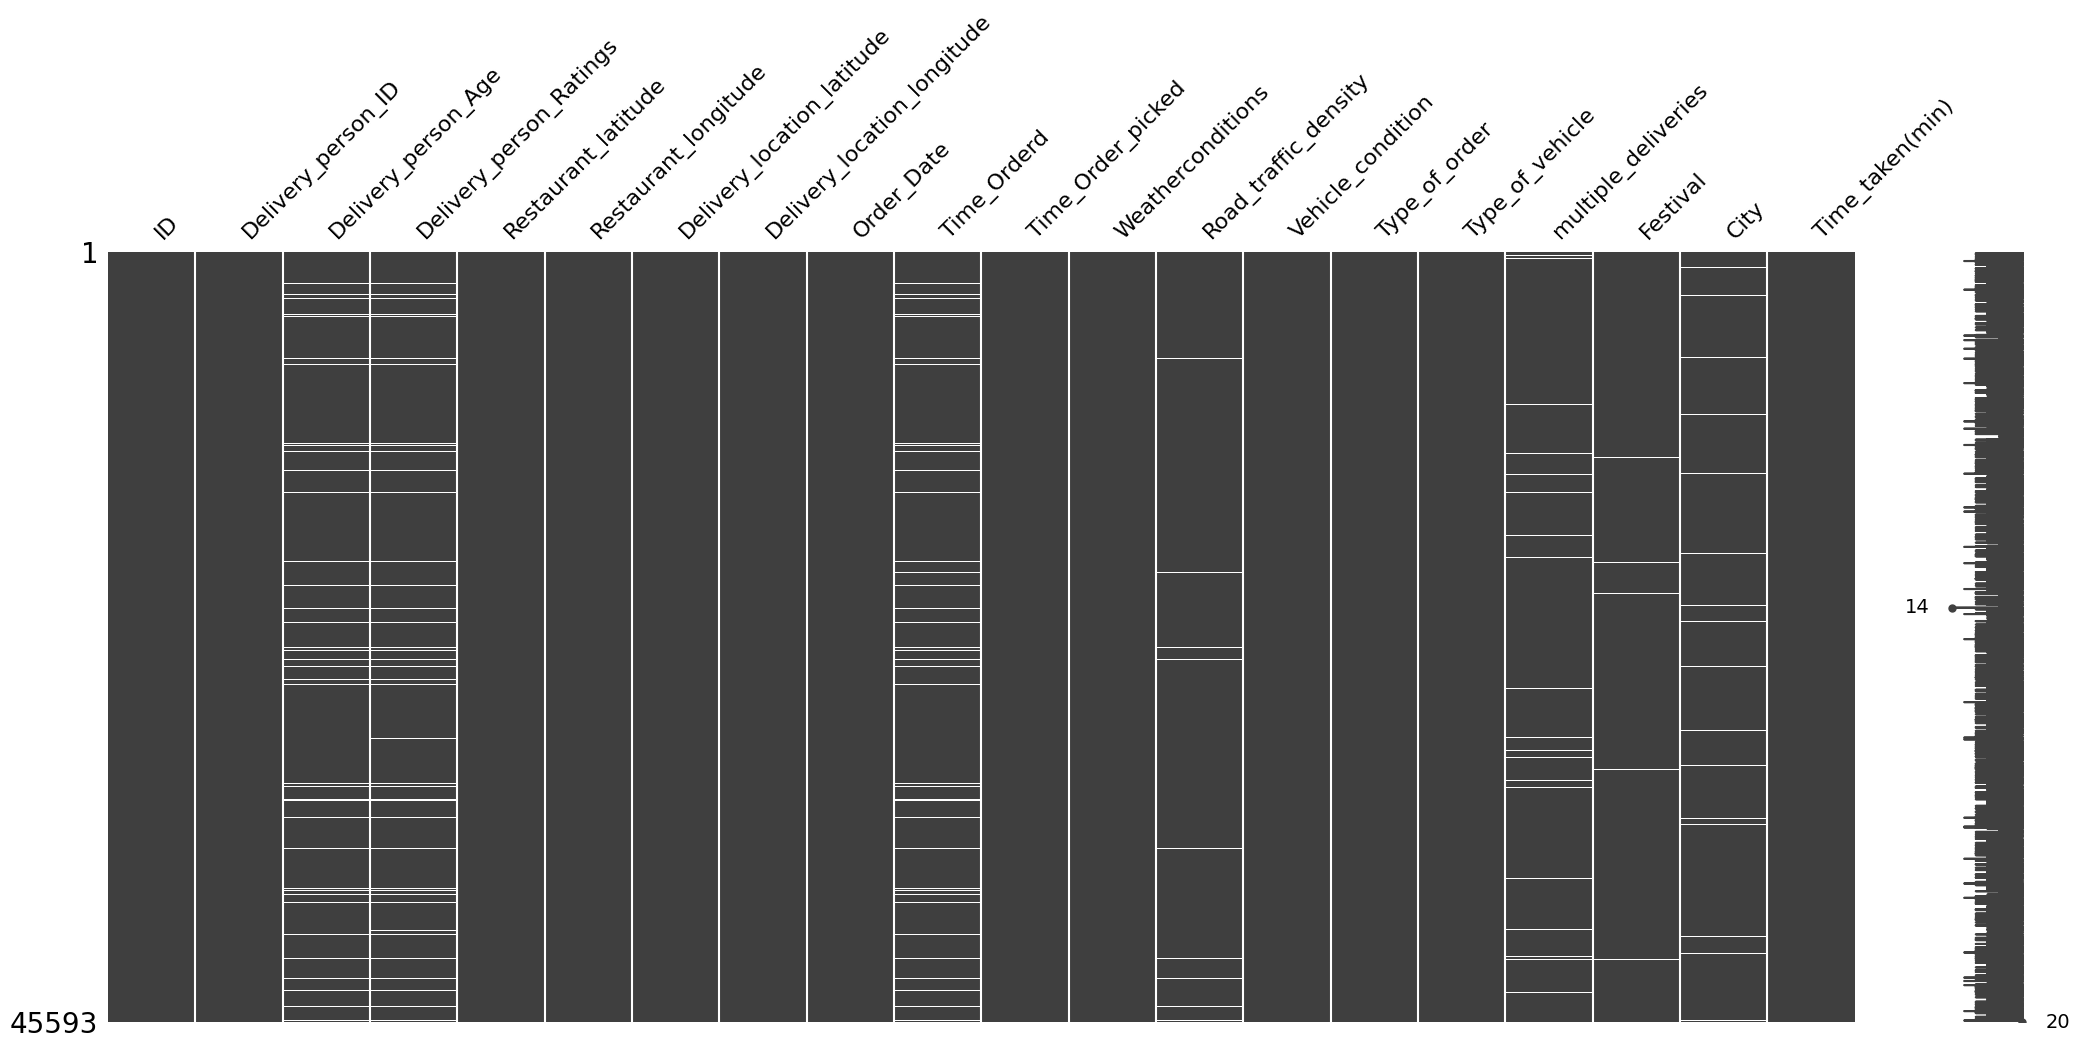

In [22]:
msn.matrix(temp_df)

<Axes: >

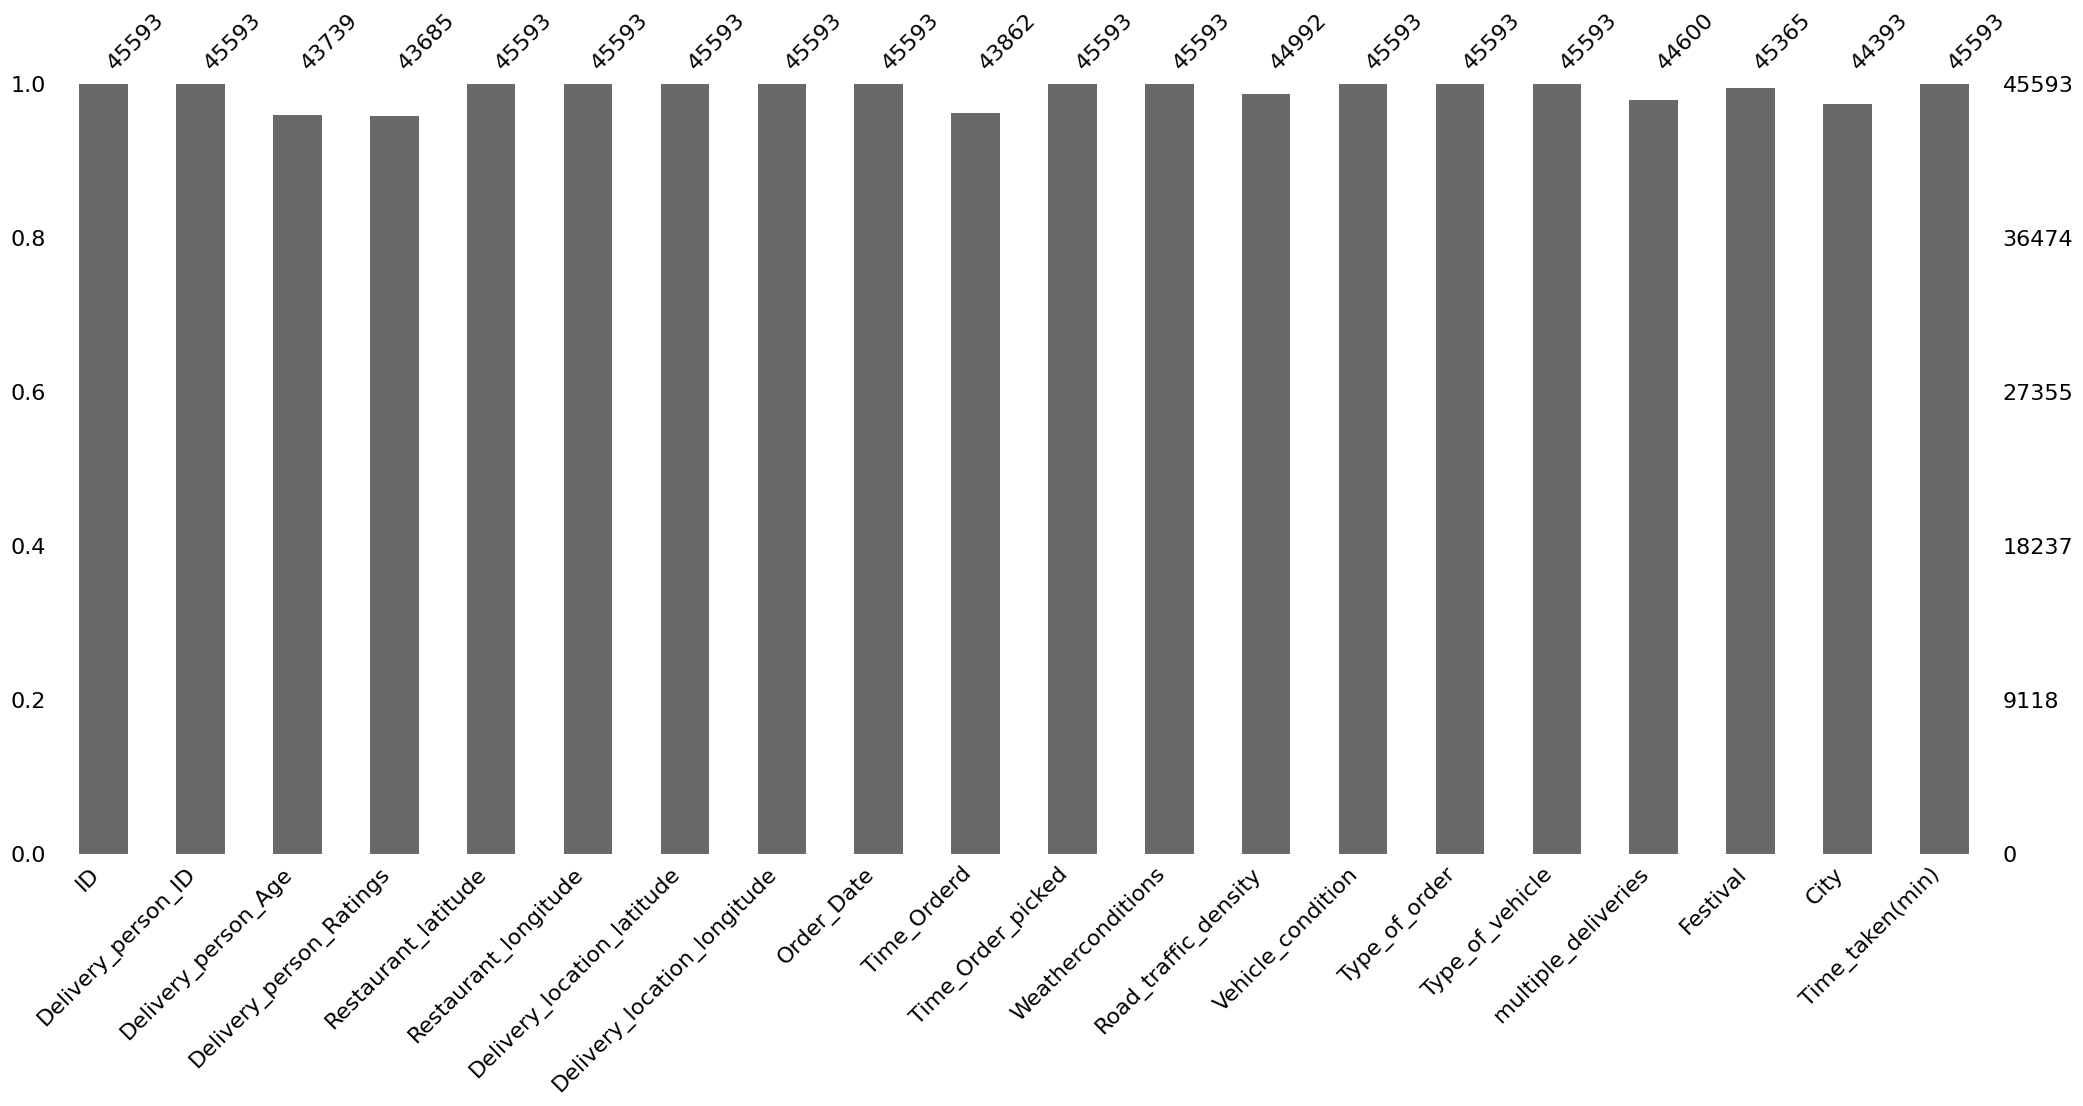

In [23]:
msn.bar(temp_df)

<Axes: >

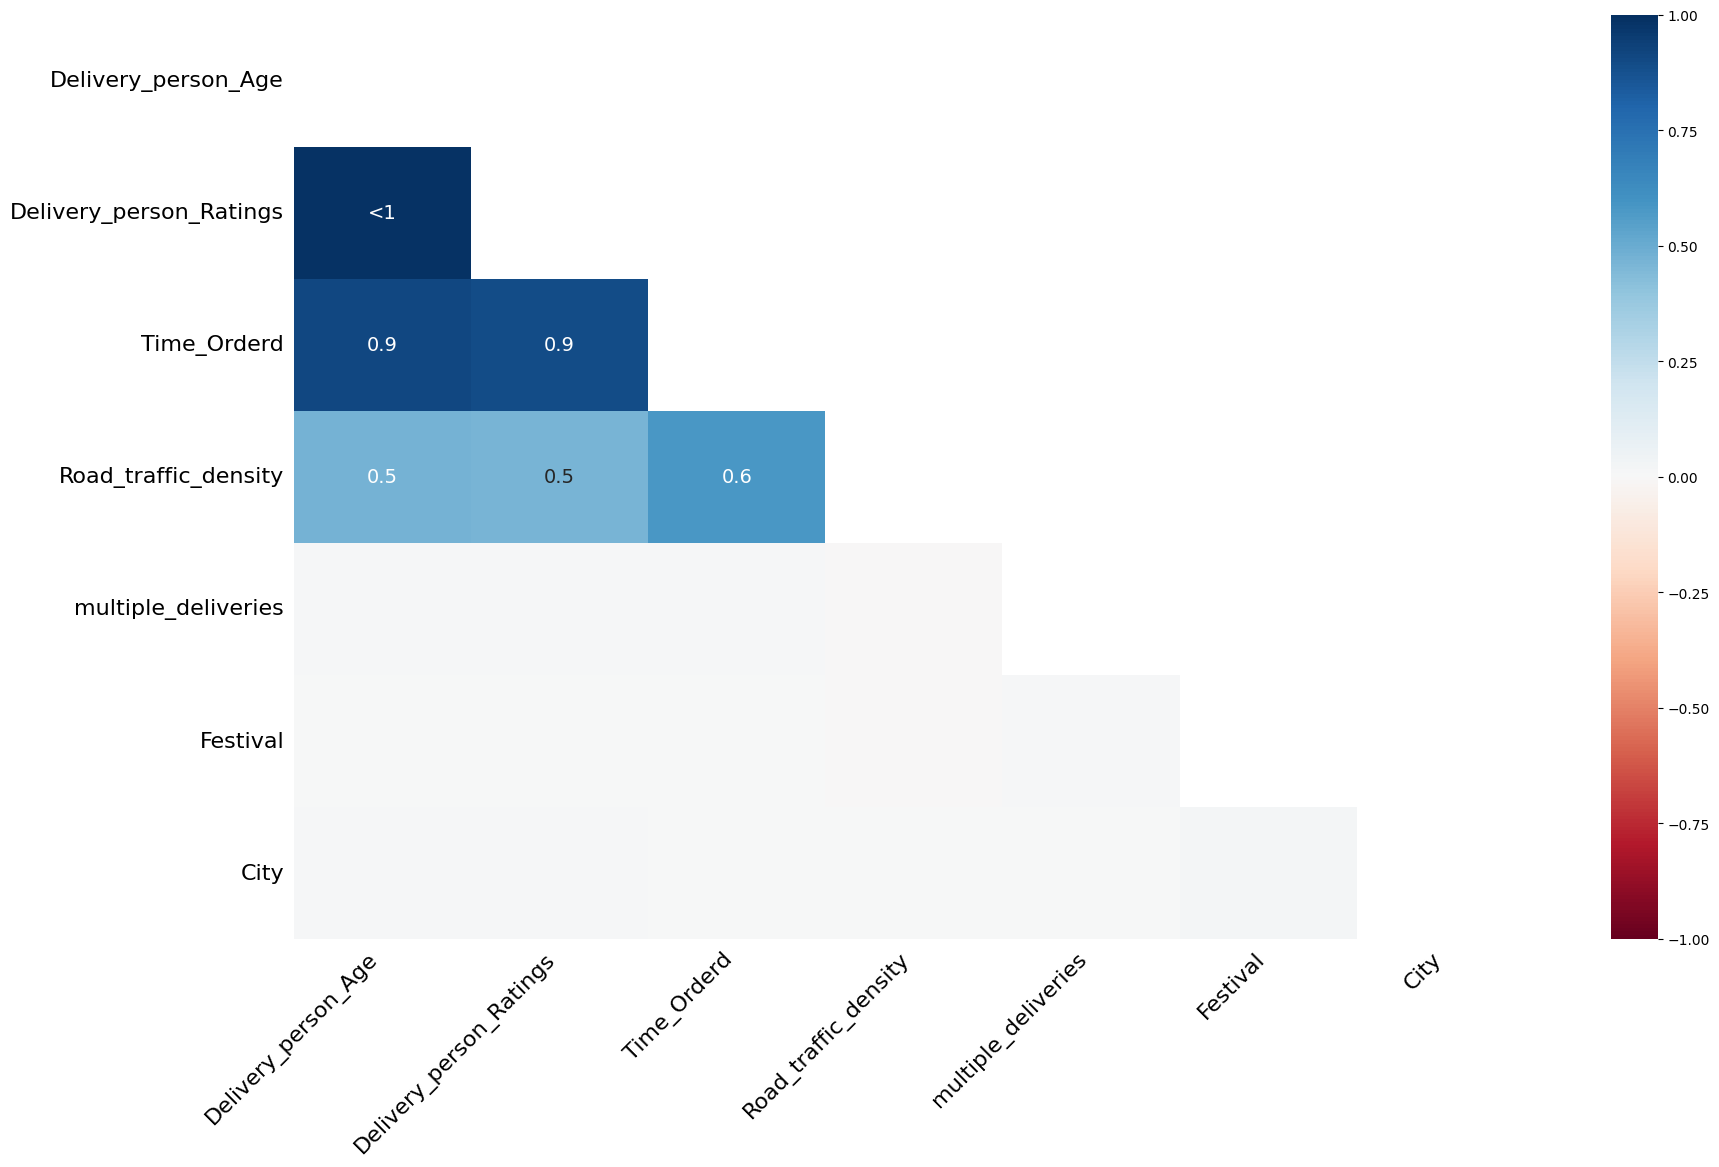

In [24]:
msn.heatmap(temp_df)

<Axes: >

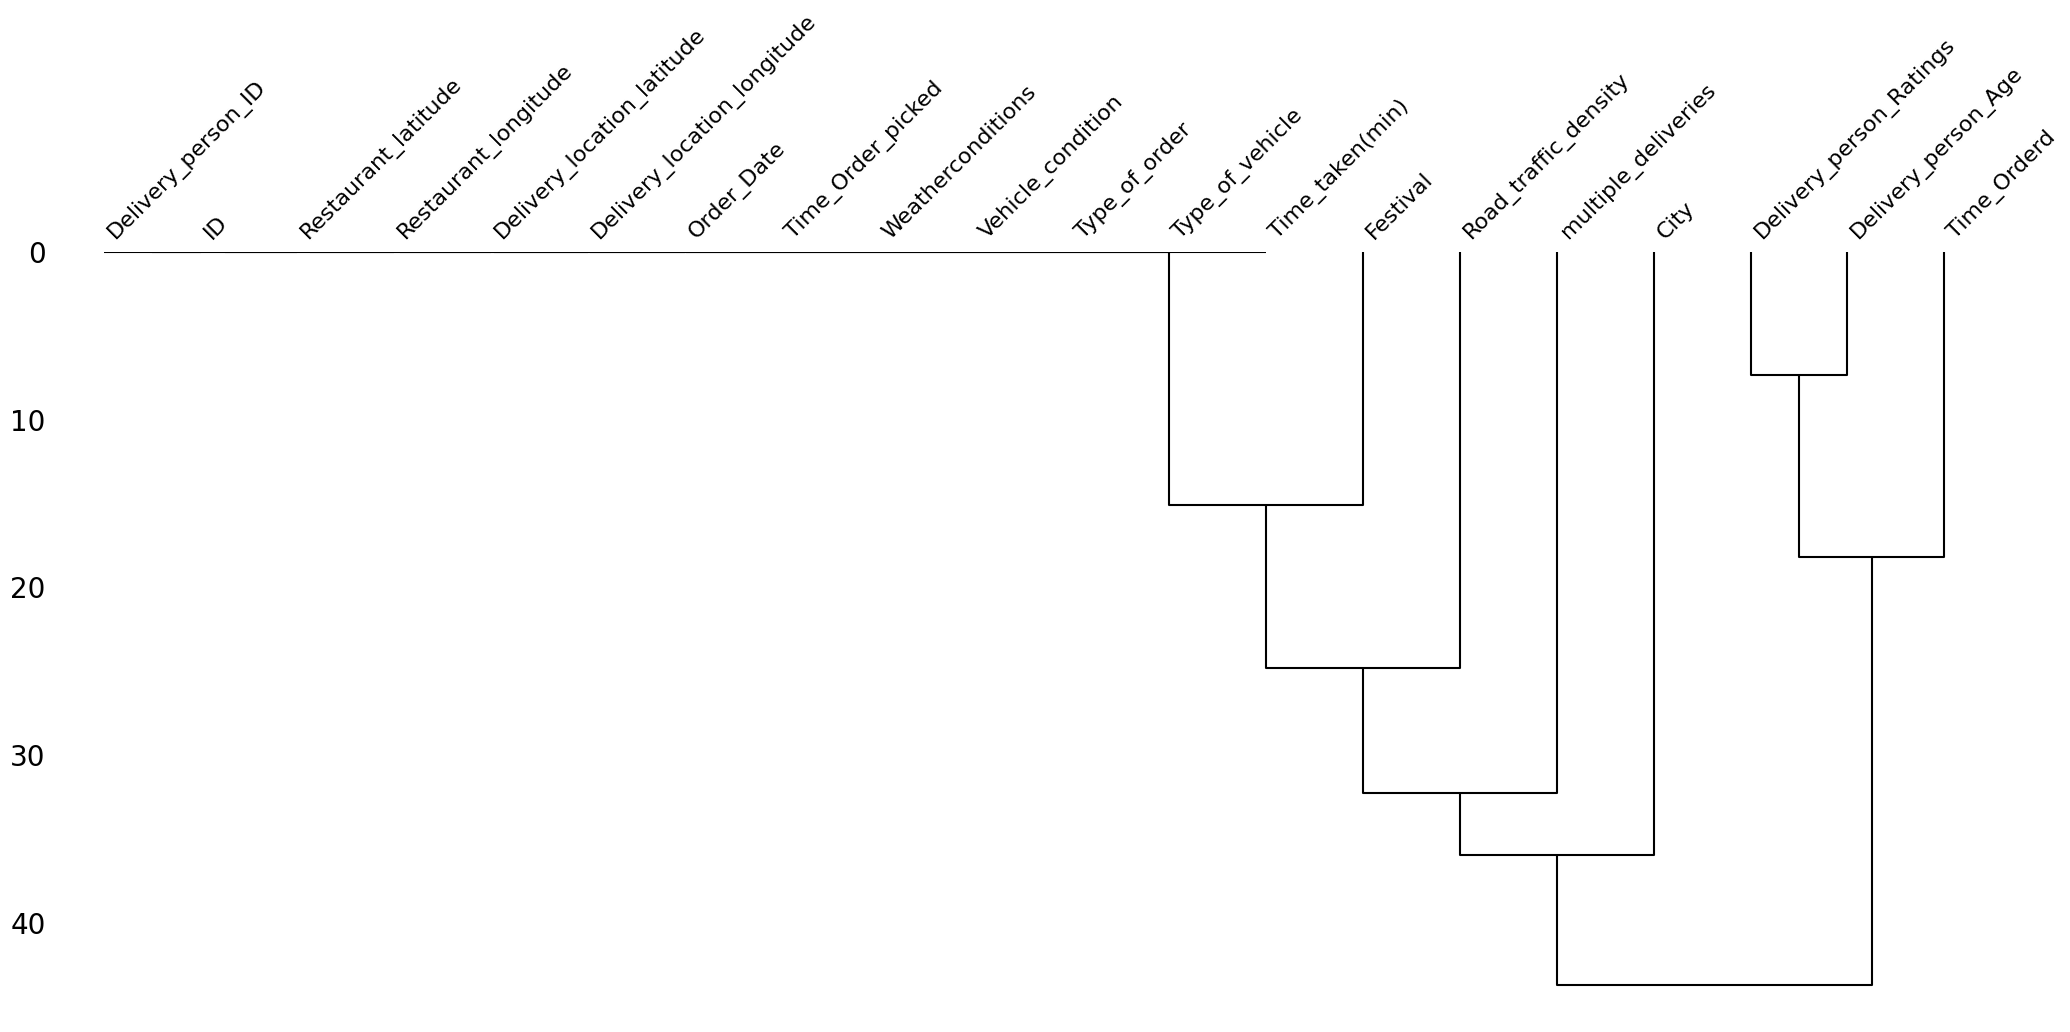

In [25]:
msn.dendrogram(temp_df)

In [26]:
(temp_df.isnull().sum().sum() * 100)/(temp_df.shape[0]*temp_df.shape[1])

np.float64(0.9338056280569386)

In [27]:
def change_column_names(data : pd.DataFrame):

    return data.rename(str.lower,axis=1).rename({
            "delivery_person_id" : "rider_id",
            "delivery_person_age": "age",
            "delivery_person_ratings": "ratings",
            "delivery_location_latitude": "delivery_latitude",
            "delivery_location_longitude": "delivery_longitude",
            "time_orderd": "order_time",
            "time_order_picked": "order_picked_time",
            "weatherconditions": "weather",
            "road_traffic_density": "traffic",
            "city": "city_type",
            "time_taken(min)": "time_taken"
    },
    axis = 1)

In [28]:
temp_df = change_column_names(temp_df)

In [29]:
temp_df.duplicated().sum()

np.int64(0)

In [30]:
temp_df['id'].nunique()

45593

In [31]:
temp_df['rider_id'].value_counts()

rider_id
JAPRES11DEL02        67
PUNERES01DEL01       67
RANCHIRES02DEL01     66
VADRES11DEL02        66
JAPRES03DEL01        66
                     ..
DEHRES18DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64

In [32]:
temp_df['rider_id'].str.split('RES').str.get(0).rename('city_name')

0          INDO
1          BANG
2          BANG
3         COIMB
4          CHEN
          ...  
45588       JAP
45589       AGR
45590      CHEN
45591     COIMB
45592    RANCHI
Name: city_name, Length: 45593, dtype: object

### age

In [33]:
temp_df['age'].dtype

<StringDtype(storage='python', na_value=nan)>

In [34]:
temp_df['age'].astype(np.float32).describe()

count    43739.000000
mean        29.567137
std          5.815156
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

<Axes: ylabel='age'>

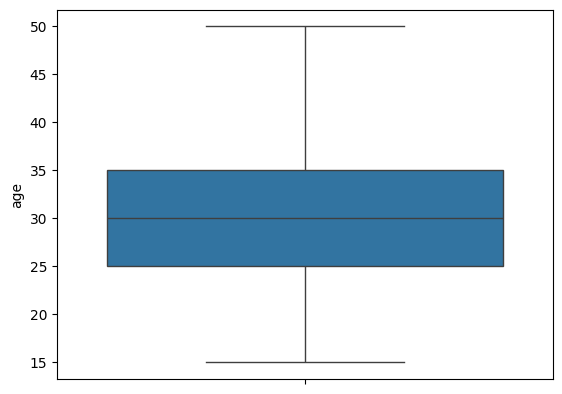

In [35]:
sns.boxplot(temp_df['age'].astype(np.float32))

In [36]:
temp_df['age'].value_counts()

age
35    2262
36    2260
37    2227
30    2226
38    2219
24    2210
32    2202
22    2196
29    2191
33    2187
28    2179
25    2174
34    2166
26    2159
21    2153
27    2150
39    2144
20    2136
31    2120
23    2087
50      53
15      38
Name: count, dtype: int64

In [37]:
age_anamoly = temp_df[(temp_df['age'].astype(float) == 15) | (temp_df['age'].astype(float) == 50)]

In [38]:
age_anamoly_index = age_anamoly.index.tolist()

### ratings

In [39]:
temp_df['ratings'].astype(float).describe()

count    43685.000000
mean         4.633780
std          0.334716
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

<Axes: ylabel='ratings'>

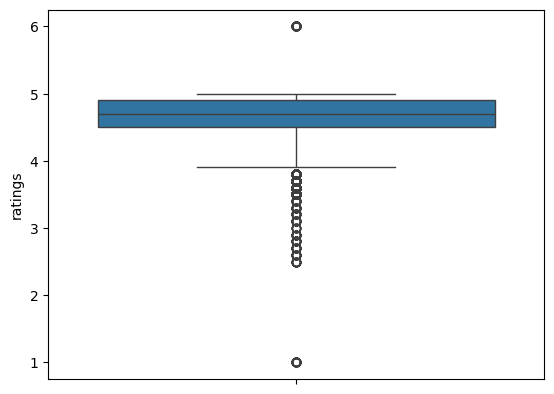

In [40]:
sns.boxplot(temp_df['ratings'].astype(float))

In [41]:
temp_df[temp_df['ratings'].astype(float) == 6][['age','ratings']].count()

age        53
ratings    53
dtype: int64

In [42]:
temp_df[temp_df['age'].astype(float) == 50][['age','ratings']].count()

age        53
ratings    53
dtype: int64

### Loaction

**Valid values for lat and long**

 > India lies to the north of the equator between `6° 44′` and `35° 30′` north latitude and `68° 7′` and `97° 25′` east longitude.

In [43]:
location_df = temp_df.iloc[:,4:8]

In [44]:
location_df

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


In [45]:
#Nil Rows having :
higher_bound_lat = 35.30
higher_bound_long = 97.25

location_df[(location_df['restaurant_latitude'] > higher_bound_lat) | 
(location_df['restaurant_longitude'] > higher_bound_long) | 
(location_df['delivery_latitude'] > higher_bound_lat) | 
(location_df['delivery_longitude'] > higher_bound_long)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude


In [46]:
# set the lower bound limits for the lat and long

lower_bound_lat = 6.44
lower_bound_long = 68.70

In [47]:
location_df[(location_df['restaurant_latitude'] < lower_bound_lat) | 
(location_df['restaurant_longitude'] < lower_bound_long) | 
(location_df['delivery_latitude'] < lower_bound_lat) | 
(location_df['delivery_longitude'] < lower_bound_long)].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,-2.149416,2.068601,2.212538,8.299885
std,6.537913,25.270676,6.538283,23.980011
min,-30.905562,-88.366217,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

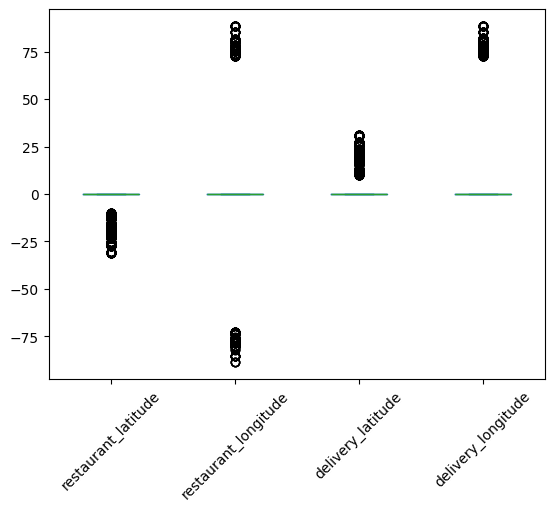

In [48]:
location_df[(location_df['restaurant_latitude'] < lower_bound_lat) | 
(location_df['restaurant_longitude'] < lower_bound_long) | 
(location_df['delivery_latitude'] < lower_bound_lat) | 
(location_df['delivery_longitude'] < lower_bound_long)].plot(kind = 'box')
plt.xticks(rotation = 45)

(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

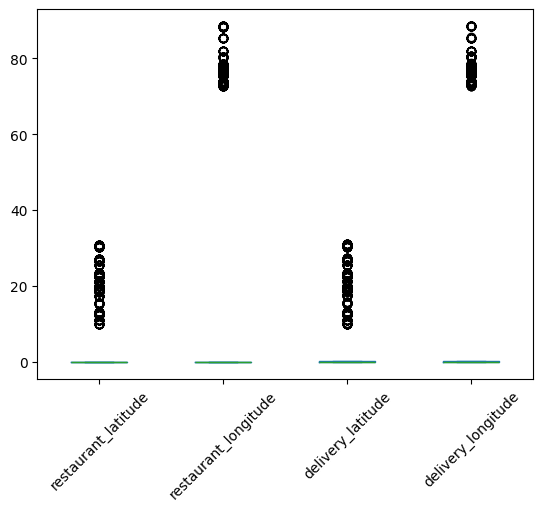

In [49]:
# abs values

location_df[(location_df['restaurant_latitude'] < lower_bound_lat) | 
(location_df['restaurant_longitude'] < lower_bound_long) | 
(location_df['delivery_latitude'] < lower_bound_lat) | 
(location_df['delivery_longitude'] < lower_bound_long)].abs().plot(kind = 'box')
plt.xticks(rotation = 45)

(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

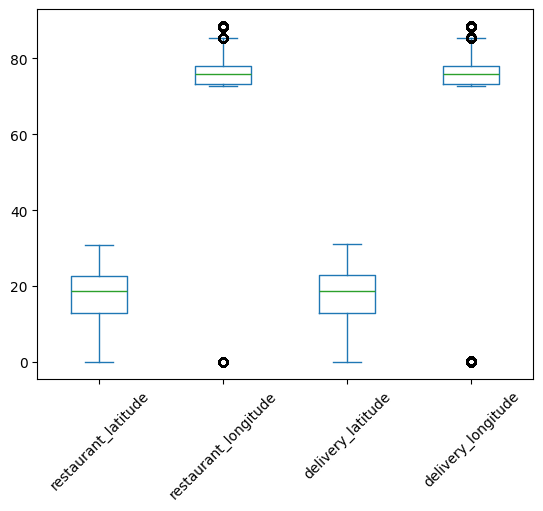

In [50]:
location_df.abs().plot(kind = 'box')
plt.xticks(rotation = 45)

In [51]:
def clean_lat_long(data:pd.DataFrame,threshold=1):

    lat_long_columns = location_df.columns.to_list()

    return (data.assign(**{
        col : (np.where(data[col]<threshold,np.nan,data[col].values)) for col in lat_long_columns
    }))

In [52]:
clean_lat_long(location_df).isnull().sum()

restaurant_latitude     4071
restaurant_longitude    3802
delivery_latitude       3640
delivery_longitude      3640
dtype: int64

### Order date

In [53]:
temp_df['order_date'].isnull().sum()

np.int64(0)

In [54]:
temp_df['order_date'].nunique()

44

In [55]:
order_date = pd.to_datetime(temp_df['order_date'],dayfirst=True)

In [56]:
order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [57]:
print('Start date :', order_date.min())
print('End date :', order_date.max())

Start date : 2022-02-11 00:00:00
End date : 2022-04-06 00:00:00


In [58]:
def extract_datetime_features(series:pd.Series):

    date_col = pd.to_datetime(series,dayfirst=True)

    return (
        pd.DataFrame(
            {
                "day" : date_col.dt.day,
                "month" : date_col.dt.month,
                "year" : date_col.dt.year,
                "day_name" : date_col.dt.day_name(),
                "is_weekend" : date_col.dt.day_name().isin(['Saturday','Sunday']).astype(int)
            }
        )
    )

In [59]:
extract_datetime_features(temp_df['order_date'])

,day,month,year,day_name,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
45588,24,3,2022,Thursday,0
45589,16,2,2022,Wednesday,0
45590,11,3,2022,Friday,0
45591,7,3,2022,Monday,0


### order time & order_picked_time

In [60]:
(temp_df['order_time']=='NaN').astype(int).sum()

np.int64(0)

In [61]:
order_time_hr = pd.to_datetime(temp_df['order_time'],format='mixed').dt.hour
order_time_hr

0        11.0
1        19.0
2         8.0
3        18.0
4        13.0
         ... 
45588    11.0
45589    19.0
45590    23.0
45591    13.0
45592    17.0
Name: order_time, Length: 45593, dtype: float64

In [62]:
# NaN value getting replace in default
# def time_of_the_day(series : pd.Series):

#     time_col = pd.to_datetime(series,format='mixed').dt.hour

#     return (
#         np.select(condlist=[
#             (time_col.between(6,12,inclusive='left')),
#             (time_col.between(12,17,inclusive='left')),
#             (time_col.between(17,20,inclusive='left')),
#             (time_col.between(20,24,inclusive='left'))
#         ],
#             choicelist=['morning','afternoon','evening','night'],
#             default='after_midnight'
#         )
#     )

In [63]:
# NaN values will remain as it is
def time_of_the_day(series : pd.Series):

    time_col = pd.to_datetime(series,format='mixed').dt.hour

    return (
        pd.cut(time_col,right=True,bins=[0,6,12,17,20,24],
               labels=['after_midnight','morning','afternoon','evening','night'])
    )

In [64]:
time_of_the_day(temp_df['order_time'])

0          morning
1          evening
2          morning
3          evening
4        afternoon
           ...    
45588      morning
45589      evening
45590        night
45591    afternoon
45592    afternoon
Name: order_time, Length: 45593, dtype: category
Categories (5, str): ['after_midnight' < 'morning' < 'afternoon' < 'evening' < 'night']

In [65]:
order_df = temp_df[['order_time','order_picked_time']]
order_df

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
...,...,...
45588,11:35:00,11:45:00
45589,19:55:00,20:10:00
45590,23:50:00,00:05:00
45591,13:35:00,13:40:00


In [66]:
order_df.assign(**{
    col : pd.to_datetime(order_df[col].dropna(),format='mixed') for col in order_df.columns.to_list()
}).assign(
    time_to_pick_min = lambda x : (x['order_picked_time'] - x['order_time']).dt.seconds/60,
    order_time_hour = lambda x : x['order_time'].dt.hour,
    order_time_of_the_day = lambda x : x['order_time'].pipe(time_of_the_day)
).drop(columns=['order_time','order_picked_time'])

,time_to_pick_min,order_time_hour,order_time_of_the_day
0,15.0,11.0,morning
1,5.0,19.0,evening
2,15.0,8.0,morning
3,10.0,18.0,evening
4,15.0,13.0,afternoon
...,...,...,...
45588,10.0,11.0,morning
45589,15.0,19.0,evening
45590,15.0,23.0,night
45591,5.0,13.0,afternoon


### Weather

In [67]:
temp_df['weather'].value_counts()

weather
fog           7654
stormy        7586
cloudy        7536
sandstorms    7495
windy         7422
sunny         7284
nan            616
Name: count, dtype: int64

In [68]:
temp_df['weather'].unique()

<StringArray>
[' sunny', ' stormy', ' sandstorms', ' cloudy', ' fog', ' windy', ' nan']
Length: 7, dtype: str

In [69]:
temp_df['weather'].nunique()

7

In [70]:
temp_df['weather'].isnull().sum()

np.int64(0)

In [71]:
temp_df['weather'].str.strip().str.lower().replace('nan',np.nan).unique()

<StringArray>
['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
Length: 7, dtype: str

In [72]:
temp_df['weather'].str.strip().str.lower().replace('nan',np.nan).isnull().sum()

np.int64(616)

In [73]:
temp_df['weather'].str.strip().str.lower().replace('nan',np.nan)

0             sunny
1            stormy
2        sandstorms
3             sunny
4            cloudy
            ...    
45588         windy
45589         windy
45590        cloudy
45591        cloudy
45592           fog
Name: weather, Length: 45593, dtype: str

### Traffic

In [74]:
temp_df['traffic'].value_counts()

traffic
Low        15477
Jam        14143
Medium     10947
High        4425
Name: count, dtype: int64

In [75]:
temp_df['traffic'].str.strip().str.lower()

0          high
1           jam
2           low
3        medium
4          high
          ...  
45588      high
45589       jam
45590       low
45591      high
45592    medium
Name: traffic, Length: 45593, dtype: str

In [76]:
temp_df['traffic'].str.strip().str.lower().unique()

<StringArray>
['high', 'jam', 'low', 'medium', nan]
Length: 5, dtype: str

In [77]:
temp_df['traffic'].isnull().sum()

np.int64(601)

### Vehicle condition

In [78]:
temp_df['vehicle_condition'].value_counts()

vehicle_condition
2    15034
1    15030
0    15009
3      520
Name: count, dtype: int64

In [79]:
temp_df['vehicle_condition'].nunique()

4

In [80]:
np.sort(temp_df['vehicle_condition'].unique())

array([0, 1, 2, 3])

### Type of Order

In [81]:
temp_df['type_of_order'].value_counts()

type_of_order
Snack      11533
Meal       11458
Drinks     11322
Buffet     11280
Name: count, dtype: int64

In [82]:
temp_df['type_of_order'].unique()

<StringArray>
['Snack ', 'Drinks ', 'Buffet ', 'Meal ']
Length: 4, dtype: str

In [83]:
temp_df['type_of_order'].str.strip().str.lower().unique()

<StringArray>
['snack', 'drinks', 'buffet', 'meal']
Length: 4, dtype: str

### Type of Vehicle

In [84]:
temp_df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           26435
scooter              15276
electric_scooter      3814
bicycle                 68
Name: count, dtype: int64

In [85]:
temp_df['type_of_vehicle'].unique()

<StringArray>
['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle ']
Length: 4, dtype: str

In [86]:
temp_df['type_of_vehicle'].str.strip().str.lower()

0        motorcycle
1           scooter
2        motorcycle
3        motorcycle
4           scooter
            ...    
45588    motorcycle
45589    motorcycle
45590       scooter
45591    motorcycle
45592       scooter
Name: type_of_vehicle, Length: 45593, dtype: str

In [87]:
temp_df['type_of_vehicle'].str.strip().str.lower().unique()

<StringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4, dtype: str

### Multiple Deliveries

In [88]:
temp_df['multiple_deliveries']

0        0
1        1
2        1
3        1
4        1
        ..
45588    0
45589    1
45590    0
45591    1
45592    1
Name: multiple_deliveries, Length: 45593, dtype: str

In [89]:
temp_df['multiple_deliveries'].value_counts()

multiple_deliveries
1    28159
0    14095
2     1985
3      361
Name: count, dtype: int64

In [90]:
temp_df['multiple_deliveries'].unique()

<StringArray>
['0', '1', '3', nan, '2']
Length: 5, dtype: str

In [91]:
temp_df['multiple_deliveries'].isnull().sum()

np.int64(993)

In [92]:
temp_df['multiple_deliveries'].astype(float)

0        0.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
45588    0.0
45589    1.0
45590    0.0
45591    1.0
45592    1.0
Name: multiple_deliveries, Length: 45593, dtype: float64

In [93]:
temp_df['multiple_deliveries'].astype(float).unique()

array([ 0.,  1.,  3., nan,  2.])

### festival

In [94]:
temp_df['festival'].value_counts()

festival
No      44469
Yes       896
Name: count, dtype: int64

In [95]:
temp_df['festival'].unique()

<StringArray>
['No ', 'Yes ', nan]
Length: 3, dtype: str

In [96]:
temp_df['festival'].str.lower().str.strip().unique()

<StringArray>
['no', 'yes', nan]
Length: 3, dtype: str

### City type

In [97]:
temp_df['city_type'].unique()

<StringArray>
['Urban ', 'Metropolitian ', 'Semi-Urban ', nan]
Length: 4, dtype: str

In [98]:
temp_df['city_type'].str.lower().str.strip()

0                urban
1        metropolitian
2                urban
3        metropolitian
4        metropolitian
             ...      
45588    metropolitian
45589    metropolitian
45590    metropolitian
45591    metropolitian
45592    metropolitian
Name: city_type, Length: 45593, dtype: str

In [99]:
temp_df['city_type'].str.lower().str.strip().unique()

<StringArray>
['urban', 'metropolitian', 'semi-urban', nan]
Length: 4, dtype: str

### Time taken

In [100]:
temp_df['time_taken']

0        (min) 24
1        (min) 33
2        (min) 26
3        (min) 21
4        (min) 30
           ...   
45588    (min) 32
45589    (min) 36
45590    (min) 16
45591    (min) 26
45592    (min) 36
Name: time_taken, Length: 45593, dtype: str

In [101]:
temp_df['time_taken'].str.split().str.get(1).astype(int)

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: time_taken, Length: 45593, dtype: int64

## Performing Cleaning and feature building

In [102]:
df.sample()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
25732,0x71e9,INDORES13DEL01,36,4.7,22.745049,75.892471,22.785049,75.932471,07-03-2022,14:45:00,14:50:00,conditions Fog,High,1,Snack,scooter,1,No,Metropolitian,(min) 38


In [103]:
df = change_column_names(df)
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken'],
      dtype='str')

In [104]:
def data_cleaning(data: pd.DataFrame):

    return (
        data
        .drop(columns="id")
        .drop(index=age_anamoly_index)                                                #age anamoly data dropped
        .replace("NaN ",np.nan)                                                 # missing values in the data
        .assign(
            # city column out of rider id
            city_name = lambda x: x['rider_id'].str.split("RES").str.get(0),
            # convert age to float
            age = lambda x: x['age'].astype(float),
            # convert ratings to float
            ratings = lambda x: x['ratings'].astype(float),
            # absolute values for location based columns
            restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
            restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
            delivery_latitude = lambda x: x['delivery_latitude'].abs(),
            delivery_longitude = lambda x: x['delivery_longitude'].abs(),
            # order date to datetime and feature extraction
            order_date = lambda x: pd.to_datetime(x['order_date'],
                                                  dayfirst=True),
            order_day = lambda x: x['order_date'].dt.day,
            order_month = lambda x: x['order_date'].dt.month,
            order_day_of_week = lambda x: x['order_date'].dt.day_name().str.lower(),
            is_weekend = lambda x: (x['order_date']
                                    .dt.day_name()
                                    .isin(["Saturday","Sunday"])
                                    .astype(int)),
            # time based columns
            order_time = lambda x: pd.to_datetime(x['order_time'],
                                                  format='mixed'),
            order_picked_time = lambda x: pd.to_datetime(x['order_picked_time'],
                                                         format='mixed'),
            # time taken to pick order
            pickup_time_minutes = lambda x: (
                                            (x['order_picked_time'] - x['order_time'])
                                            .dt.seconds / 60
                                            ),
            # hour in which order was placed
            order_time_hour = lambda x: x['order_time'].dt.hour,
            # time of the day when order was placed
            order_time_of_day = lambda x: (
                                x['order_time'].pipe(time_of_the_day)),
            # categorical columns
            weather = lambda x: (
                                x['weather']
                                .str.replace("conditions ","")
                                .str.lower()
                                .replace("nan",np.nan)),
            traffic = lambda x: x["traffic"].str.rstrip().str.lower(),
            type_of_order = lambda x: x['type_of_order'].str.rstrip().str.lower(),
            type_of_vehicle = lambda x: x['type_of_vehicle'].str.rstrip().str.lower(),
            festival = lambda x: x['festival'].str.rstrip().str.lower(),
            city_type = lambda x: x['city_type'].str.rstrip().str.lower(),
            # multiple deliveries column
            multiple_deliveries = lambda x: x['multiple_deliveries'].astype(float),
            # target column modifications
            time_taken = lambda x: (x['time_taken']
                                    .str.replace("(min) ","")
                                    .astype(int)))
        .drop(columns=["order_time","order_picked_time"])
    )

In [105]:
data_cleaning(df)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,metropolitian,32,JAP,24,3,thursday,0,10.0,11.0,morning
45589,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,windy,jam,...,metropolitian,36,AGR,16,2,wednesday,0,15.0,19.0,evening
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,metropolitian,16,CHEN,11,3,friday,0,15.0,23.0,night
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,metropolitian,26,COIMB,7,3,monday,0,5.0,13.0,afternoon


In [106]:
def calculate_haversine_distance(df):
    location_columns = location_df.columns.tolist()
    lat1 = df[location_columns[0]]
    lon1 = df[location_columns[1]]
    lat2 = df[location_columns[2]]
    lon2 = df[location_columns[3]]

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    distance = 6371 * c

    return (
        df.assign(
            distance = distance)
    )

In [107]:
def create_distance_type(data:pd.DataFrame):
    return (
        data.assign(
            distance_type = pd.cut(data['distance'],bins=[0,5,10,15,25],right=False,
                                   labels = ['short','medium','long','very_long'])
        )
    )

In [ ]:
# add more data cleaning steps

cleaned_data = (
                df.pipe(data_cleaning)
                .pipe(clean_lat_long)
                .pipe(calculate_haversine_distance)
                .pipe(create_distance_type)
                )

cleaned_data

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45589,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


### Validate Data

In [109]:
# age column

cleaned_data['age'].agg(["min","max"])

min    20.0
max    39.0
Name: age, dtype: float64

In [110]:
cleaned_data['ratings'].agg(['min','max'])

min    2.5
max    5.0
Name: ratings, dtype: float64

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


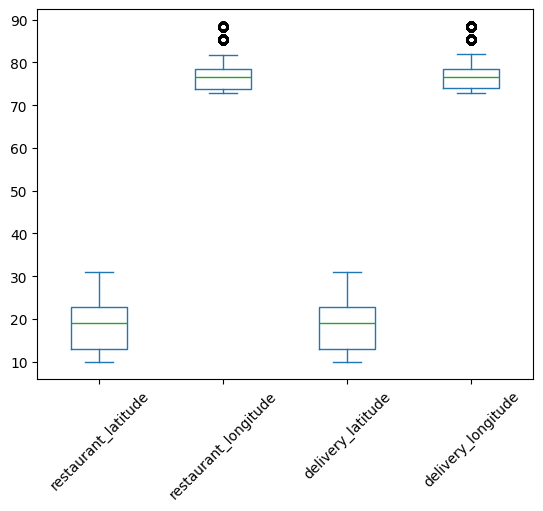

In [111]:
# location columns

cleaned_data[location_df.columns].plot(kind="box")

plt.xticks(rotation=45)

display(cleaned_data[location_df.columns].describe())

In [112]:
# values in categorical columns

cat_cols = cleaned_data.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    print(f"For {col} unique values are: {cleaned_data[col].unique()}",end="\n\n")

For rider_id unique values are: <StringArray>
[  'INDORES13DEL02 ',   'BANGRES18DEL02 ',   'BANGRES19DEL01 ',
  'COIMBRES13DEL02 ',   'CHENRES12DEL01 ',    'HYDRES09DEL03 ',
 'RANCHIRES15DEL01 ',    'MYSRES15DEL02 ',    'HYDRES05DEL02 ',
    'DEHRES17DEL01 ',
 ...
    'KNPRES18DEL01 ',    'BHPRES08DEL03 ',   'AURGRES13DEL01 ',
   'LUDHRES03DEL02 ',    'KNPRES05DEL01 ',    'GOARES01DEL03 ',
    'KOCRES08DEL03 ',    'KOCRES04DEL01 ',    'BHPRES06DEL03 ',
    'GOARES03DEL03 ']
Length: 1320, dtype: str

For weather unique values are: <StringArray>
['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
Length: 7, dtype: str

For traffic unique values are: <StringArray>
['high', 'jam', 'low', 'medium', nan]
Length: 5, dtype: str

For type_of_order unique values are: <StringArray>
['snack', 'drinks', 'buffet', 'meal']
Length: 4, dtype: str

For type_of_vehicle unique values are: <StringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4, dtype: str

For festiva

C:\Users\Jay Kanakia\AppData\Local\Temp\ipykernel_11356\3367994248.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = cleaned_data.select_dtypes(include="object").columns.tolist()


### Save Cleaned Data

In [113]:
import os
os.makedirs('./data/raw/',exist_ok=True)
df.to_csv(os.path.join('./data/raw/','raw_data.csv'),index=False)

In [114]:
import os
os.makedirs('./data/processed/',exist_ok=True)
df.to_csv(os.path.join('./data/processed/','cleaned_data.csv'),index=False)

In [115]:
cleaned_data.to_csv('cleaned_data.csv',index=False)